# Neural Network Assisted Solver for Nonlinear Systems
## A Complete Tutorial Notebook in PyTorch

This notebook explains how to use a **two-stage numerical solver** for nonlinear systems of equations of the form

$
F(x)=0, \qquad F:\mathbb{R}^n \to \mathbb{R}^n.
$

The solver combines:

1. **Adam optimization** on the residual-squared loss  
   $
   \mathcal{L}(x)=\frac12 \|F(x)\|_2^2
   $
2. **Newton refinement** using the autodiff Jacobian

This is not a symbolic exact solver. It is a **high-precision numerical solver framework** that is often effective in practice.

---

## What you will learn

By the end of this notebook, you will know how to:

- define a nonlinear system $(F(x))$
- instantiate the solver
- choose an initial guess
- run the two-stage solve pipeline
- inspect convergence histories
- compute the Jacobian
- adapt the framework to your own research problems

## Conceptual overview

The method proceeds in two stages.

### Stage 1: Adam preconditioning

Instead of solving $(F(x)=0)$ directly, we minimize

$
\mathcal{L}(x)=\frac12 \|F(x)\|^2.
$

This gives a point that is hopefully close to a true root.

### Stage 2: Newton refinement

Once the iterate is close enough, we switch to Newton updates

$
J_F(x_k)\,\Delta x = -F(x_k), \qquad x_{k+1}=x_k+\Delta x,
$

where $(J_F(x))$ is the Jacobian matrix.

This often yields very rapid local convergence.

In [13]:
from dataclasses import dataclass
from typing import Callable, List, Optional, Tuple

import matplotlib.pyplot as plt
import torch

torch.set_default_dtype(torch.float64)
Tensor = torch.Tensor

## Solver implementation

The following class is the full implementation of the solver.
You can use it directly in your own projects.

In [14]:
@dataclass
class SolveResult:
    x: Tensor
    success: bool
    stage1_steps: int
    stage2_steps: int
    final_residual_norm: float
    final_loss: float
    history_stage1: List[float]
    history_stage2: List[float]
    message: str


class NeuralNonlinearSystemSolver:
    """
    Solve F(x) = 0 using:
      1) Adam on residual-squared loss
      2) Newton refinement with autodiff Jacobian

    This is not a symbolic exact solver.
    It is a high-precision numerical solver framework.
    """

    def __init__(
        self,
        func: Callable[[Tensor], Tensor],
        dim: int,
        device: Optional[torch.device] = None,
        dtype: torch.dtype = torch.float64,
    ) -> None:
        self.func = func
        self.dim = dim
        self.device = device or torch.device("cpu")
        self.dtype = dtype

    def _ensure_vector(self, x: Tensor) -> Tensor:
        x = x.to(device=self.device, dtype=self.dtype)
        if x.ndim != 1 or x.shape[0] != self.dim:
            raise ValueError(f"x must have shape ({self.dim},), got {tuple(x.shape)}")
        return x

    def residual(self, x: Tensor) -> Tensor:
        x = self._ensure_vector(x)
        fx = self.func(x)
        if fx.ndim != 1 or fx.shape[0] != self.dim:
            raise ValueError(
                f"func(x) must return shape ({self.dim},), got {tuple(fx.shape)}"
            )
        return fx

    def loss(self, x: Tensor) -> Tensor:
        fx = self.residual(x)
        return 0.5 * torch.dot(fx, fx)

    def jacobian(self, x: Tensor) -> Tensor:
        x = self._ensure_vector(x).detach().clone().requires_grad_(True)

        def wrapped(inp: Tensor) -> Tensor:
            return self.func(inp)

        J = torch.autograd.functional.jacobian(
            wrapped, x, create_graph=False, strict=False
        )
        if J.ndim != 2 or J.shape != (self.dim, self.dim):
            raise RuntimeError(
                f"Jacobian shape mismatch: expected {(self.dim, self.dim)}, got {tuple(J.shape)}"
            )
        return J.detach()

    def solve_stage1_adam(
        self,
        x0: Tensor,
        lr: float = 1e-2,
        max_steps: int = 5000,
        tol_grad: float = 1e-12,
        tol_residual: float = 1e-8,
        print_every: int = 0,
    ) -> Tuple[Tensor, List[float], int]:
        x = self._ensure_vector(x0).detach().clone().requires_grad_(True)
        optimizer = torch.optim.Adam([x], lr=lr)

        history: List[float] = []

        for step in range(1, max_steps + 1):
            optimizer.zero_grad(set_to_none=True)
            loss = self.loss(x)
            loss.backward()

            grad_norm = float(x.grad.norm().item()) if x.grad is not None else float("inf")
            residual_norm = float(self.residual(x.detach()).norm().item())
            history.append(residual_norm)

            if print_every > 0 and (step % print_every == 0 or step == 1):
                print(
                    f"[Adam] step={step:5d}  "
                    f"loss={loss.item():.6e}  "
                    f"residual={residual_norm:.6e}  "
                    f"grad={grad_norm:.6e}"
                )

            if residual_norm < tol_residual:
                return x.detach(), history, step

            if grad_norm < tol_grad:
                return x.detach(), history, step

            optimizer.step()

        return x.detach(), history, max_steps

    def _linear_solve(self, J: Tensor, rhs: Tensor, reg_lambda: float = 0.0) -> Tensor:
        if reg_lambda > 0.0:
            J = J + reg_lambda * torch.eye(
                self.dim, device=J.device, dtype=J.dtype
            )

        try:
            dx = torch.linalg.solve(J, rhs)
        except RuntimeError:
            dx = torch.linalg.lstsq(J, rhs.unsqueeze(-1)).solution.squeeze(-1)
        return dx

    def solve_stage2_newton(
        self,
        x0: Tensor,
        max_steps: int = 50,
        tol_residual: float = 1e-12,
        tol_step: float = 1e-14,
        damping: bool = True,
        min_step_scale: float = 1e-6,
        reg_lambda: float = 0.0,
        print_every: int = 1,
    ) -> Tuple[Tensor, List[float], int, bool, str]:
        x = self._ensure_vector(x0).detach().clone()
        history: List[float] = []

        for step in range(1, max_steps + 1):
            fx = self.residual(x)
            residual_norm = float(fx.norm().item())
            history.append(residual_norm)

            if print_every > 0:
                print(f"[Newton] step={step:3d}  residual={residual_norm:.6e}")

            if residual_norm < tol_residual:
                return x, history, step, True, "Residual tolerance reached."

            J = self.jacobian(x)
            dx = self._linear_solve(J, -fx, reg_lambda=reg_lambda)

            step_norm = float(dx.norm().item())
            if step_norm < tol_step:
                new_residual_norm = float(self.residual(x).norm().item())
                success = new_residual_norm < tol_residual
                msg = "Newton step norm below tolerance."
                return x, history, step, success, msg

            if not damping:
                x = x + dx
                continue

            current_norm = residual_norm
            alpha = 1.0
            accepted = False

            while alpha >= min_step_scale:
                x_trial = x + alpha * dx
                trial_norm = float(self.residual(x_trial).norm().item())

                if trial_norm < current_norm:
                    x = x_trial
                    accepted = True
                    break

                alpha *= 0.5

            if not accepted:
                return (
                    x,
                    history,
                    step,
                    False,
                    "Line search failed to reduce residual.",
                )

        final_norm = float(self.residual(x).norm().item())
        success = final_norm < tol_residual
        msg = "Reached maximum Newton iterations."
        return x, history, max_steps, success, msg

    def solve(
        self,
        x0: Tensor,
        adam_lr: float = 1e-2,
        adam_steps: int = 5000,
        adam_tol_residual: float = 1e-8,
        adam_tol_grad: float = 1e-12,
        newton_steps: int = 50,
        newton_tol_residual: float = 1e-12,
        newton_tol_step: float = 1e-14,
        damping: bool = True,
        min_step_scale: float = 1e-6,
        reg_lambda: float = 0.0,
        verbose: bool = True,
    ) -> SolveResult:
        x0 = self._ensure_vector(x0)

        x_stage1, hist1, s1 = self.solve_stage1_adam(
            x0=x0,
            lr=adam_lr,
            max_steps=adam_steps,
            tol_grad=adam_tol_grad,
            tol_residual=adam_tol_residual,
            print_every=200 if verbose else 0,
        )

        x_final, hist2, s2, success, msg = self.solve_stage2_newton(
            x0=x_stage1,
            max_steps=newton_steps,
            tol_residual=newton_tol_residual,
            tol_step=newton_tol_step,
            damping=damping,
            min_step_scale=min_step_scale,
            reg_lambda=reg_lambda,
            print_every=1 if verbose else 0,
        )

        final_fx = self.residual(x_final)
        final_residual_norm = float(final_fx.norm().item())
        final_loss = float(0.5 * torch.dot(final_fx, final_fx).item())

        return SolveResult(
            x=x_final,
            success=success,
            stage1_steps=s1,
            stage2_steps=s2,
            final_residual_norm=final_residual_norm,
            final_loss=final_loss,
            history_stage1=hist1,
            history_stage2=hist2,
            message=msg,
        )

## Utility functions

These helpers print a clean summary and plot the residual history.

In [15]:
def plot_histories(result: SolveResult, title_prefix: str = "Convergence") -> None:
    plt.figure(figsize=(8, 5))
    plt.semilogy(result.history_stage1, label="Stage 1: Adam")
    if len(result.history_stage2) > 0:
        offset = len(result.history_stage1)
        plt.semilogy(
            range(offset, offset + len(result.history_stage2)),
            result.history_stage2,
            label="Stage 2: Newton",
        )
    plt.xlabel("Iteration")
    plt.ylabel(r"$\|F(x)\|_2$")
    plt.title(f"{title_prefix}: Residual Norm History")
    plt.grid(True)
    plt.legend()
    plt.show()


def summarize_result(result: SolveResult, solver: NeuralNonlinearSystemSolver) -> None:
    print("========== Solve Summary ==========")
    print(f"success                = {result.success}")
    print(f"message                = {result.message}")
    print(f"stage1_steps (Adam)    = {result.stage1_steps}")
    print(f"stage2_steps (Newton)  = {result.stage2_steps}")
    print(f"x*                     = {result.x}")
    print(f"F(x*)                  = {solver.residual(result.x)}")
    print(f"final_residual_norm    = {result.final_residual_norm:.6e}")
    print(f"final_loss             = {result.final_loss:.6e}")

# Part I — First complete example

We start with the nonlinear system

$
\begin{cases}
x^2 + y^2 - 5 = 0,\\
x - y - 1 = 0.
\end{cases}
$

This is a good first example because it is nonlinear, low-dimensional, and has multiple roots.

In [16]:
def system_2d(x: Tensor) -> Tensor:
    x1, x2 = x[0], x[1]
    return torch.stack([
        x1**2 + x2**2 - 5.0,
        x1 - x2 - 1.0,
    ])

solver_2d = NeuralNonlinearSystemSolver(
    func=system_2d,
    dim=2,
    dtype=torch.float64,
)

## Step 1: choose an initial guess

For nonlinear systems, the initial guess matters.
Different initial guesses can converge to different roots.

In [17]:
x0 = torch.tensor([1.5, 0.5], dtype=torch.float64)
print("Initial guess:", x0)
print("Initial residual F(x0) =", solver_2d.residual(x0))
print("Initial loss =", solver_2d.loss(x0).item())
print("Initial Jacobian J(x0) =\n", solver_2d.jacobian(x0))

Initial guess: tensor([1.5000, 0.5000])
Initial residual F(x0) = tensor([-2.5000,  0.0000])
Initial loss = 3.125
Initial Jacobian J(x0) =
 tensor([[ 3.,  1.],
        [ 1., -1.]])


## Step 2: run the full solve pipeline

In [18]:
result_2d = solver_2d.solve(
    x0=x0,
    adam_lr=1e-2,
    adam_steps=3000,
    adam_tol_residual=1e-10,
    adam_tol_grad=1e-14,
    newton_steps=30,
    newton_tol_residual=1e-14,
    newton_tol_step=1e-15,
    damping=True,
    reg_lambda=0.0,
    verbose=True,
)

[Adam] step=    1  loss=3.125000e+00  residual=2.500000e+00  grad=7.905694e+00
[Adam] step=  200  loss=1.646465e-05  residual=5.738406e-03  grad=8.919939e-03
[Adam] step=  400  loss=2.119156e-09  residual=6.510232e-05  grad=9.720774e-05
[Adam] step=  600  loss=8.607570e-16  residual=4.149113e-08  grad=6.195434e-08
[Newton] step=  1  residual=9.147224e-11
[Newton] step=  2  residual=0.000000e+00


## Step 3: inspect the result

========== Solve Summary ==========
success                = True
message                = Residual tolerance reached.
stage1_steps (Adam)    = 696
stage2_steps (Newton)  = 2
x*                     = tensor([2., 1.])
F(x*)                  = tensor([0., 0.])
final_residual_norm    = 0.000000e+00
final_loss             = 0.000000e+00


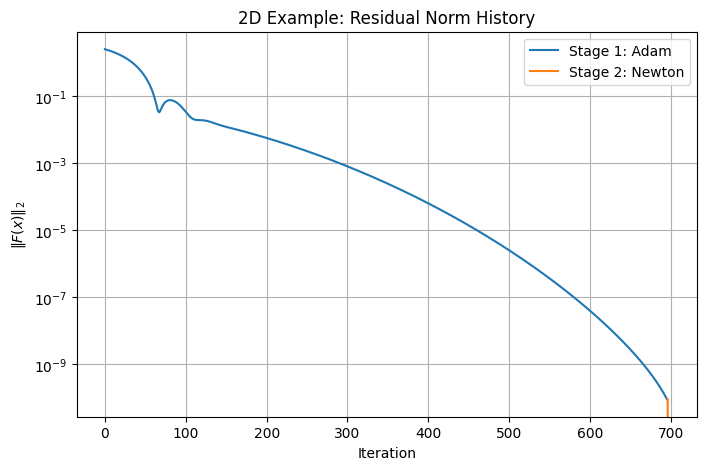

In [19]:
summarize_result(result_2d, solver_2d)
plot_histories(result_2d, title_prefix="2D Example")

## Interpretation

The final vector `result_2d.x` is the numerical root candidate $(x^\star)$.

The most important verification is not the printed vector itself, but the residual norm

$
\|F(x^\star)\|.
$

If the residual norm is very small, the solution is numerically reliable.

# Part II — Reusable template

To use this solver on your own system, you only need to:

1. define a function `my_system(x)` returning shape `(dim,)`
2. instantiate `NeuralNonlinearSystemSolver`
3. choose an initial guess
4. call `.solve(...)`
5. verify the residual

========== Solve Summary ==========
success                = True
message                = Residual tolerance reached.
stage1_steps (Adam)    = 324
stage2_steps (Newton)  = 2
x*                     = tensor([ 1.0000e+00, -8.6440e-17])
F(x*)                  = tensor([-1.1102e-16,  0.0000e+00])
final_residual_norm    = 1.110223e-16
final_loss             = 6.162976e-33


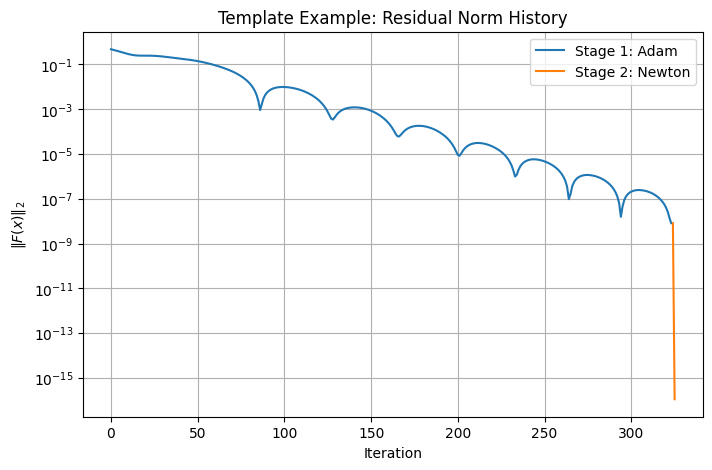

In [20]:
def my_system_example(x: Tensor) -> Tensor:
    x0, x1 = x
    return torch.stack([
        x0 + x1 - 1.0,
        x0**2 + x1**2 - 1.0,
    ])


my_solver = NeuralNonlinearSystemSolver(
    func=my_system_example,
    dim=2,
    dtype=torch.float64,
)

my_x0 = torch.tensor([0.7, 0.2], dtype=torch.float64)

my_result = my_solver.solve(
    x0=my_x0,
    verbose=False,
)

summarize_result(my_result, my_solver)
plot_histories(my_result, title_prefix="Template Example")

# Part III — A 3D nonlinear example

Now we solve

$
\begin{cases}
x+y+z-3=0,\\
x^2+y^2+z^2-5=0,\\
e^x+y-z^2=0.
\end{cases}
$

This shows that the same workflow extends naturally to higher dimensions.

In [21]:
def system_3d(x: Tensor) -> Tensor:
    x1, x2, x3 = x
    return torch.stack([
        x1 + x2 + x3 - 3.0,
        x1**2 + x2**2 + x3**2 - 5.0,
        torch.exp(x1) + x2 - x3**2,
    ])


solver_3d = NeuralNonlinearSystemSolver(
    func=system_3d,
    dim=3,
    dtype=torch.float64,
)

x0_3d = torch.tensor([1.0, 1.0, 1.0], dtype=torch.float64)

print("Initial residual =", solver_3d.residual(x0_3d))
print("Initial Jacobian =\n", solver_3d.jacobian(x0_3d))

Initial residual = tensor([ 0.0000, -2.0000,  2.7183])
Initial Jacobian =
 tensor([[ 1.0000,  1.0000,  1.0000],
        [ 2.0000,  2.0000,  2.0000],
        [ 2.7183,  1.0000, -2.0000]])


[Adam] step=    1  loss=5.694528e+00  residual=3.374768e+00  grad=1.010828e+01
[Adam] step=  200  loss=3.693494e-02  residual=2.717901e-01  grad=2.304210e-01
[Adam] step=  400  loss=1.427694e-03  residual=5.343582e-02  grad=5.683274e-02
[Adam] step=  600  loss=4.358304e-06  residual=2.952390e-03  grad=3.262581e-03
[Adam] step=  800  loss=1.664648e-09  residual=5.770005e-05  grad=6.389504e-05
[Adam] step= 1000  loss=6.787769e-14  residual=3.684500e-07  grad=4.080254e-07
[Adam] step= 1200  loss=1.549320e-19  residual=5.566544e-10  grad=6.164465e-10
[Newton] step=  1  residual=9.904812e-11
[Newton] step=  2  residual=0.000000e+00
========== Solve Summary ==========
success                = True
message                = Residual tolerance reached.
stage1_steps (Adam)    = 1245
stage2_steps (Newton)  = 2
x*                     = tensor([-0.1546,  1.5903,  1.5643])
F(x*)                  = tensor([0., 0., 0.])
final_residual_norm    = 0.000000e+00
final_loss             = 0.000000e+00


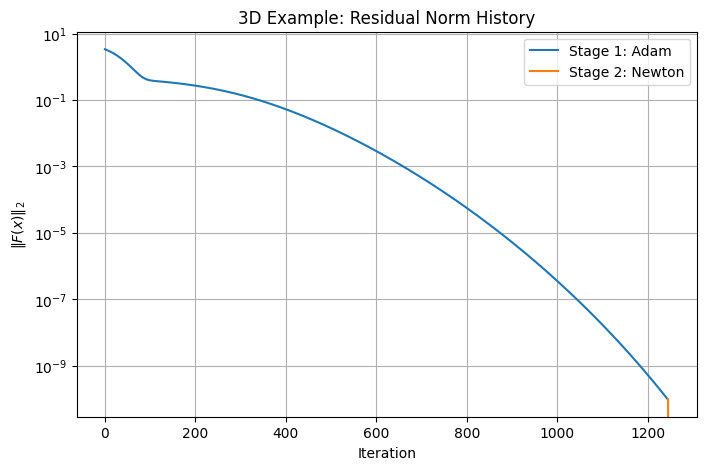

In [22]:
result_3d = solver_3d.solve(
    x0=x0_3d,
    adam_lr=1e-2,
    adam_steps=4000,
    adam_tol_residual=1e-10,
    adam_tol_grad=1e-14,
    newton_steps=40,
    newton_tol_residual=1e-13,
    newton_tol_step=1e-15,
    damping=True,
    reg_lambda=0.0,
    verbose=True,     
)

summarize_result(result_3d, solver_3d)
plot_histories(result_3d, title_prefix="3D Example")

# Part IV — Understanding the main parameters

## Adam stage

### `adam_lr`
Learning rate for the Adam stage.

- too large: unstable or oscillatory
- too small: slow convergence

Typical starting values:
- `1e-2`
- `5e-3`
- `1e-3`

### `adam_steps`
Maximum number of Adam steps.

### `adam_tol_residual`
Stop Adam early if

$
\|F(x)\| < \text{adam\_tol\_residual}.
$

### `adam_tol_grad`
Stop Adam if the gradient norm becomes tiny.

---

## Newton stage

### `newton_steps`
Maximum number of Newton iterations.

### `newton_tol_residual`
Target residual norm for the final high-precision solution.

### `newton_tol_step`
Stop if the Newton step becomes very small.

### `damping=True`
Enables backtracking line search.

### `min_step_scale`
Minimum acceptable line-search scale.

### `reg_lambda`
Adds diagonal regularization:

$
(J + \lambda I)\Delta x = -F.
$

This can help when the Jacobian is ill-conditioned.

# Part V — Troubleshooting and practical advice

## Use `float64`
Nonlinear systems are much more sensitive than standard deep-learning tasks.

## Monitor the residual
Always verify \(\|F(x)\|\), not just the solution vector.

## Try multiple initial guesses
For multi-root systems, one run may only find one root.

## If Newton fails
Try:

- a better initial guess
- more Adam iterations
- a smaller Adam learning rate
- `damping=True`
- a small `reg_lambda`

## If the Jacobian is nearly singular
Convergence may slow down or become unstable.
In that case, numerical conditioning becomes the central issue.

# Part VI — Running the two stages manually

You do not have to use the full `.solve(...)` wrapper.
You can also run the two stages separately for more control.

In [23]:
x_stage1, hist1, n1 = solver_2d.solve_stage1_adam(
    x0=torch.tensor([1.5, 0.5], dtype=torch.float64),
    lr=1e-2,
    max_steps=1000,
    tol_grad=1e-14,
    tol_residual=1e-8,
    print_every=200,
)

print("After Stage 1:")
print("x_stage1 =", x_stage1)
print("||F(x_stage1)|| =", solver_2d.residual(x_stage1).norm().item())

[Adam] step=    1  loss=3.125000e+00  residual=2.500000e+00  grad=7.905694e+00
[Adam] step=  200  loss=1.646465e-05  residual=5.738406e-03  grad=8.919939e-03
[Adam] step=  400  loss=2.119156e-09  residual=6.510232e-05  grad=9.720774e-05
[Adam] step=  600  loss=8.607570e-16  residual=4.149113e-08  grad=6.195434e-08
After Stage 1:
x_stage1 = tensor([2.0000, 1.0000])
||F(x_stage1)|| = 9.566389814296448e-09


In [24]:
x_stage2, hist2, n2, success2, msg2 = solver_2d.solve_stage2_newton(
    x0=x_stage1,
    max_steps=20,
    tol_residual=1e-14,
    tol_step=1e-15,
    damping=True,
    reg_lambda=0.0,
    print_every=1,
)

print("After Stage 2:")
print("success =", success2)
print("message =", msg2)
print("x_stage2 =", x_stage2)
print("F(x_stage2) =", solver_2d.residual(x_stage2))
print("||F(x_stage2)|| =", solver_2d.residual(x_stage2).norm().item())

[Newton] step=  1  residual=9.566390e-09
[Newton] step=  2  residual=0.000000e+00
After Stage 2:
success = True
message = Residual tolerance reached.
x_stage2 = tensor([2.0000, 1.0000])
F(x_stage2) = tensor([0., 0.])
||F(x_stage2)|| = 0.0


# Part VII — Final remarks

This notebook has shown a complete workflow:

1. define the nonlinear system  
2. instantiate the solver  
3. choose an initial guess  
4. solve numerically  
5. inspect the residual  
6. visualize convergence  

For research use, the most important habits are:

- verify the final residual
- test several initial guesses
- use `float64`
- inspect the Jacobian when needed

End of notebook.